## Thelia的手撕线性回归尝试！

### 随机生成一个数据吧

In [ ]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import time

seed = int(time.time())  # 每分钟更新一次随机种子，确保每次运行生成不同的样本
# 原函数参数 y = a * x + b
random.seed(seed)
a = random.uniform(-10, 10)  # 斜率在0.5到2.0之间随机选择
b = random.uniform(-10, 10)   # 截距在-10到10之间随机选择

# 方差与样本数（方差越大，点越分散）
noise_std = random.uniform(30, 100)  # 噪声标准差在30到100之间随机选择
n_samples = 150

rng = np.random.default_rng(seed)
x = np.arange(1, n_samples + 1)
noise = rng.normal(0, noise_std, size=n_samples)
y = a * x + b + noise

df = pd.DataFrame({
    'x': x,
    'y': np.round(y, 1),
})

csv_path = Path('linear_regression_sample.csv')
df.to_csv(csv_path, index=False)
print(f'已生成 {n_samples} 条样本，保存到: {csv_path.resolve()}')
df.head()

已生成 150 条样本，保存到: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/linear_regression_sample.csv


,x,y
0,1,-16.3
1,2,0.3
2,3,-38.5
3,4,-14.7
4,5,-17.9


### **第一步：导入包**

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **第二步：导入数据**

In [47]:
dataset = pd.read_csv('linear_regression_sample.csv')
print(dataset)
X = dataset.iloc[:, :-1].values #输入矩阵
y = dataset.iloc[:, -1].values #输出矩阵

       x      y
0      1  -16.3
1      2    0.3
2      3  -38.5
3      4  -14.7
4      5  -17.9
..   ...    ...
145  146 -863.1
146  147 -919.6
147  148 -909.9
148  149 -888.7
149  150 -934.1

[150 rows x 2 columns]


#### 试着画个散点图？

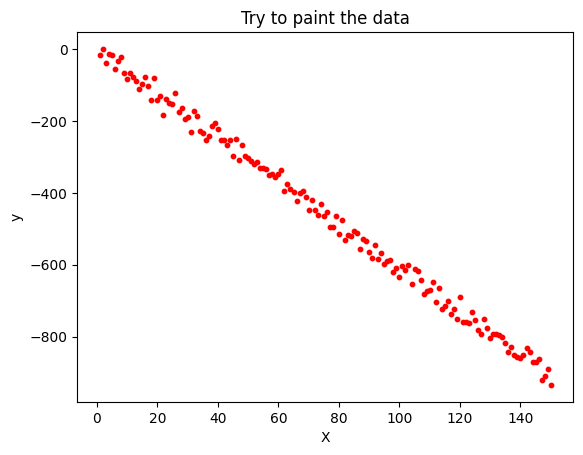

In [48]:
plt.scatter(X, y, color='red', s=10)
plt.title('Try to paint the data')
plt.xlabel('X')
plt.ylabel('y')
plt.show()